## 1. Задача

Требуется, на основании имеющихся данных о клиентах банка, построить модели (логистической регрессии, деревьев решений, ансамбль деревьев решений, любую из моделей градинтного бустинга (catboost, xgboost, lightgbm)), используя обучающий датасет, для прогнозирования невыполнения долговых обязательств по текущему кредиту. Выполнить прогноз для примеров из тестового датасета.

### Наименование файлов с данными

- `course_project_train.csv` - обучающий датасет
- `course_project_test.csv` - тестовый датасет

### Целевая переменная

`Credit Default` - факт невыполнения кредитных обязательств

### Метрики качества

- `F1-score` (sklearn.metrics.f1_score)
- `Gini` = $2  *AUC ROC - 1$

### Требования к решению

1. **Целевая метрика**

- F1 > 0.5
- Метрика оценивается по качеству прогноза для главного класса (1 - просрочка по кредиту)

2. **Использовать полный pipline разработки ML-модели**:
- `EDA-анализ` (Разведочный анализ данных)
- `Preprocessing` (предобработка данных)
- `FE` (Генерация признаков - ПРИ НЕОБХОДИМОСТИ (она не обязательно должна быть в рамках этой задачи))
- `Моделирование` (построение baseline модели, подбор гиперпараметров, валидация)

3. **Запушить ноутбук с решением в открытый репозиторий на GitHub и написать понятную документацию в формате README.md с ключевыми выводами**

4. **Повышенный уровень сложности**

- Реализовать самописный алгоритм для decision tree, random forest, gradient boosting  сравнение между метрикой, полученной по `рукописным алгоритмам`, и алгоритмам из коробки.
- Сравнить результаты по модели **логистической регрессии** и выше описанным моделям (можно только из коробки). 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

RANDOM_STATE = 42
TARGET_COL = "Credit Default"

sns.set(style="whitegrid")

In [2]:
train_url = "https://raw.githubusercontent.com/DmitryTeb/HW_DT_GB_TEBENKOV_DM/main/course_project_train.csv"
test_url = "https://raw.githubusercontent.com/DmitryTeb/HW_DT_GB_TEBENKOV_DM/main/course_project_test.csv"

train_df = pd.read_csv(train_url)
test_df = pd.read_csv(test_url)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTarget distribution:")
print(train_df[TARGET_COL].value_counts())

print("\nTarget share:")
print(train_df[TARGET_COL].value_counts(normalize=True))

Train shape: (7500, 17)
Test shape: (2500, 16)

Target distribution:
Credit Default
0    5387
1    2113
Name: count, dtype: int64

Target share:
Credit Default
0    0.718267
1    0.281733
Name: proportion, dtype: float64


# Шаг 1 — обзор структуры данных

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Home Ownership                7500 non-null   object 
 1   Annual Income                 5943 non-null   float64
 2   Years in current job          7129 non-null   object 
 3   Tax Liens                     7500 non-null   float64
 4   Number of Open Accounts       7500 non-null   float64
 5   Years of Credit History       7500 non-null   float64
 6   Maximum Open Credit           7500 non-null   float64
 7   Number of Credit Problems     7500 non-null   float64
 8   Months since last delinquent  3419 non-null   float64
 9   Bankruptcies                  7486 non-null   float64
 10  Purpose                       7500 non-null   object 
 11  Term                          7500 non-null   object 
 12  Current Loan Amount           7500 non-null   float64
 13  Cur

In [6]:
missing = train_df.isna().mean().sort_values(ascending=False)
missing.head(15)

Months since last delinquent    0.544133
Credit Score                    0.207600
Annual Income                   0.207600
Years in current job            0.049467
Bankruptcies                    0.001867
Purpose                         0.000000
Monthly Debt                    0.000000
Current Credit Balance          0.000000
Current Loan Amount             0.000000
Term                            0.000000
Home Ownership                  0.000000
Number of Credit Problems       0.000000
Maximum Open Credit             0.000000
Years of Credit History         0.000000
Number of Open Accounts         0.000000
dtype: float64

### Определяем типы признаков

In [7]:
X = train_df.drop(columns=[TARGET_COL])

cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("Количество числовых признаков:", len(num_cols))
print("Количество категориальных признаков:", len(cat_cols))

print("\nЧисловые признаки:")
print(num_cols)

print("\nКатегориальные признаки:")
print(cat_cols)

Количество числовых признаков: 12
Количество категориальных признаков: 4

Числовые признаки:
['Annual Income', 'Tax Liens', 'Number of Open Accounts', 'Years of Credit History', 'Maximum Open Credit', 'Number of Credit Problems', 'Months since last delinquent', 'Bankruptcies', 'Current Loan Amount', 'Current Credit Balance', 'Monthly Debt', 'Credit Score']

Категориальные признаки:
['Home Ownership', 'Years in current job', 'Purpose', 'Term']


In [8]:
train_df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Annual Income,5943.0,1.366392e+06,8.453392e+05,164597.0,844341.0,1168386.0,1640137.00,1.014934e+07
Tax Liens,7500.0,3.013333e-02,2.716035e-01,0.0,0.0,0.0,0.00,7.000000e+00
Number of Open Accounts,7500.0,1.113093e+01,4.908924e+00,2.0,8.0,10.0,14.00,4.300000e+01
Years of Credit History,7500.0,1.831747e+01,7.041946e+00,4.0,13.5,17.0,21.80,5.770000e+01
Maximum Open Credit,7500.0,9.451537e+05,1.602622e+07,0.0,279229.5,478159.0,793501.50,1.304726e+09
Number of Credit Problems,7500.0,1.700000e-01,4.985978e-01,0.0,0.0,0.0,0.00,7.000000e+00
Months since last delinquent,3419.0,3.469260e+01,2.168881e+01,0.0,16.0,32.0,50.00,1.180000e+02
Bankruptcies,7486.0,1.171520e-01,3.471917e-01,0.0,0.0,0.0,0.00,4.000000e+00
Current Loan Amount,7500.0,1.187318e+07,3.192612e+07,11242.0,180169.0,309573.0,519882.00,1.000000e+08
Current Credit Balance,7500.0,2.898332e+05,3.178714e+05,0.0,114256.5,209323.0,360406.25,6.506797e+06


# Шаг 3 — распределения признаков

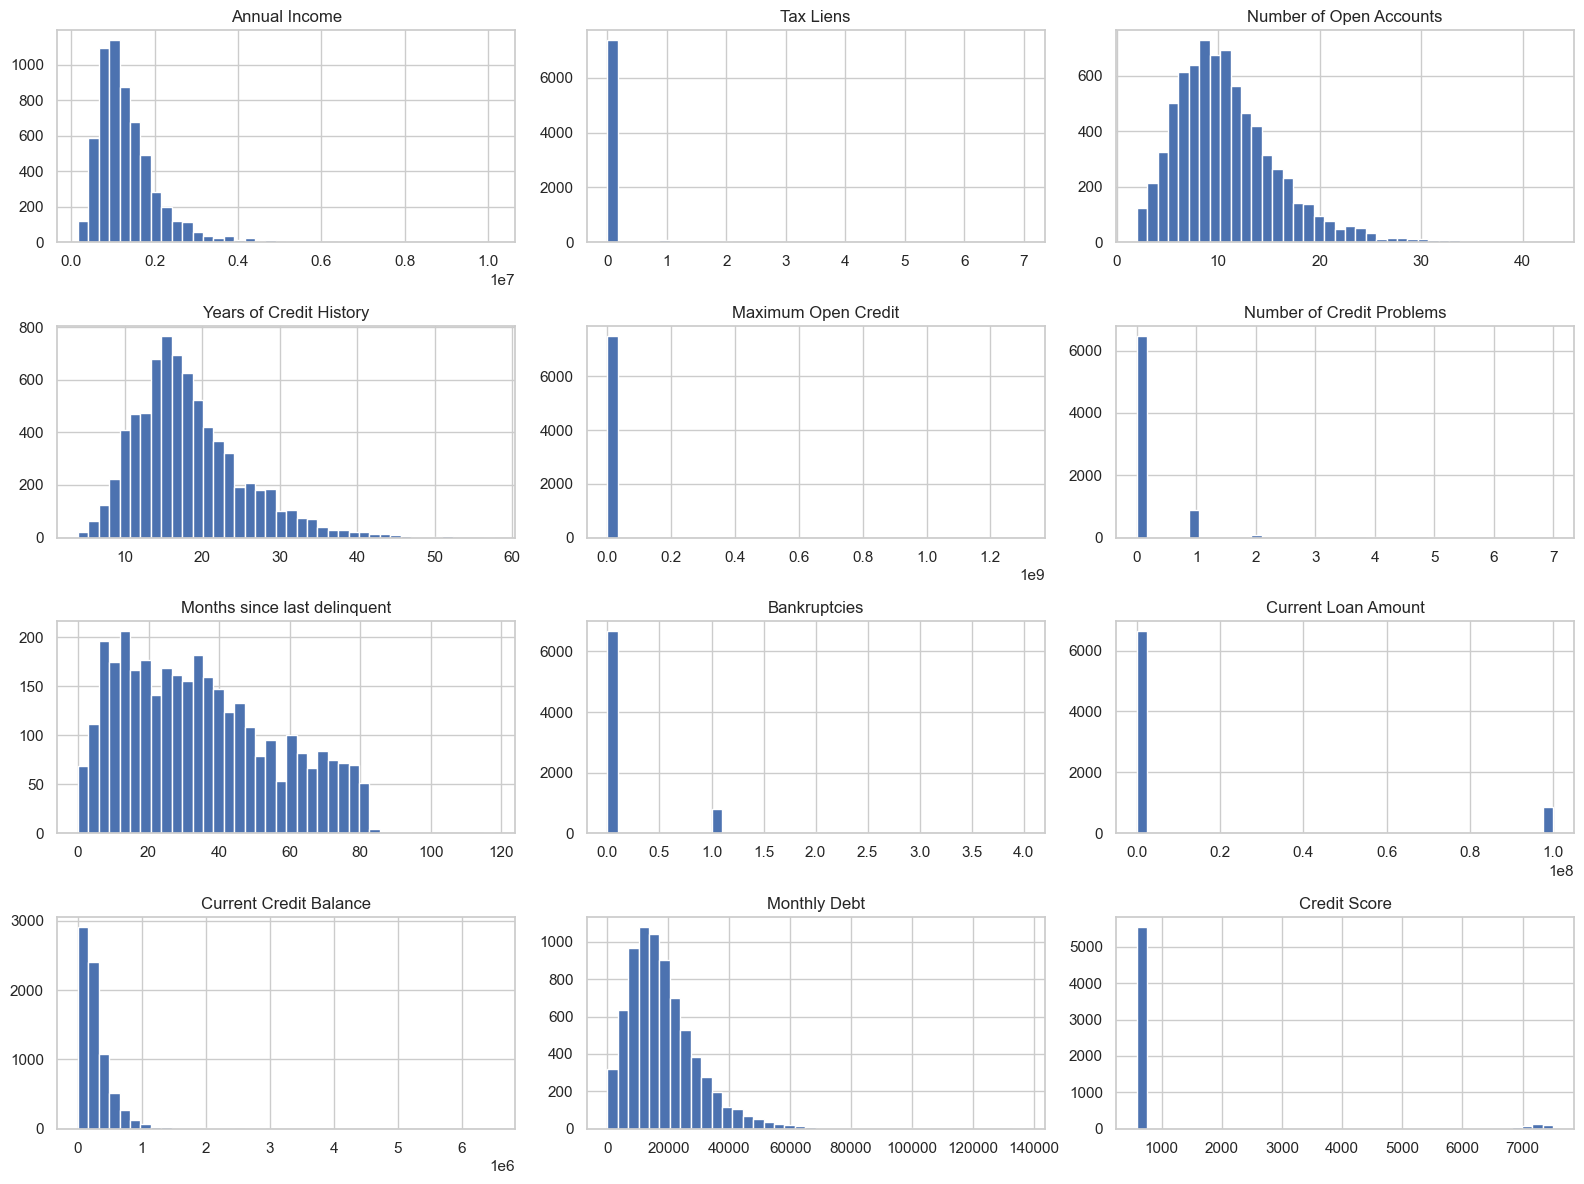

In [9]:
train_df[num_cols].hist(figsize=(16,12), bins=40)
plt.tight_layout()
plt.show()

# Шаг 4 — распределение target

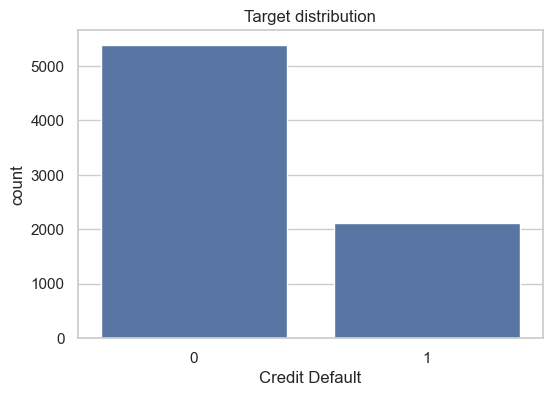

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x=train_df[TARGET_COL])
plt.title("Target distribution")
plt.show()

# Шаг 5 — boxplot (поиск выбросов)

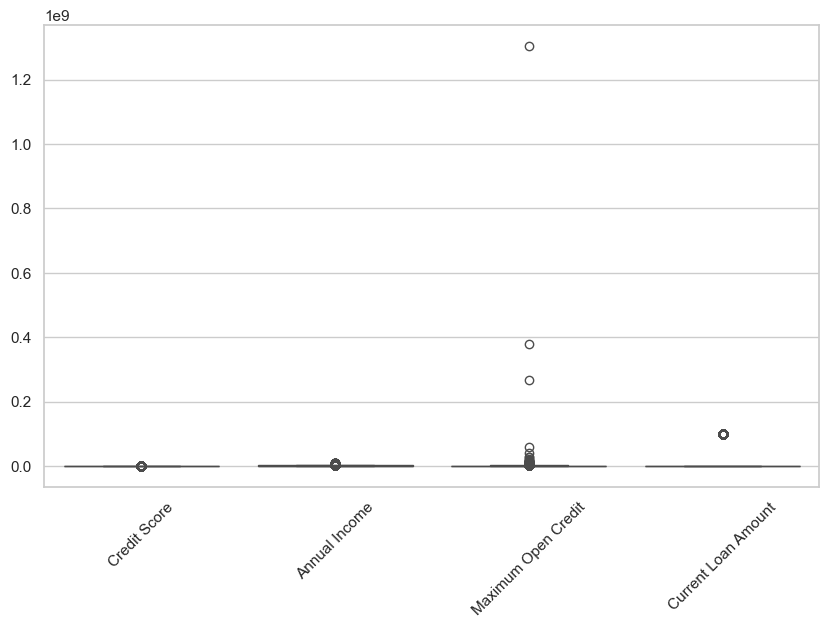

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(data=train_df[[
    "Credit Score",
    "Annual Income",
    "Maximum Open Credit",
    "Current Loan Amount"
]])
plt.xticks(rotation=45)
plt.show()

# Шаг 4 — Feature Engineering

### Создадим новые признаки.

### Debt-to-Income (DTI)

In [13]:
train_df["DTI"] = train_df["Monthly Debt"] / (train_df["Annual Income"] / 12)
test_df["DTI"] = test_df["Monthly Debt"] / (test_df["Annual Income"] / 12)

### Negative Records

In [14]:
train_df["Negative_Records"] = (
    train_df["Number of Credit Problems"]
    + train_df["Bankruptcies"]
    + train_df["Tax Liens"]
)

test_df["Negative_Records"] = (
    test_df["Number of Credit Problems"]
    + test_df["Bankruptcies"]
    + test_df["Tax Liens"]
)

In [15]:
train_df[["DTI", "Negative_Records"]].describe()

,DTI,Negative_Records
count,5943.000000,7486.000000
mean,0.171363,0.317660
std,0.079256,0.932212
min,0.000000,0.000000
25%,0.112000,0.000000
50%,0.167005,0.000000
75%,0.227003,0.000000
max,0.399009,14.000000


# Шаг 5 — корреляционная матрица

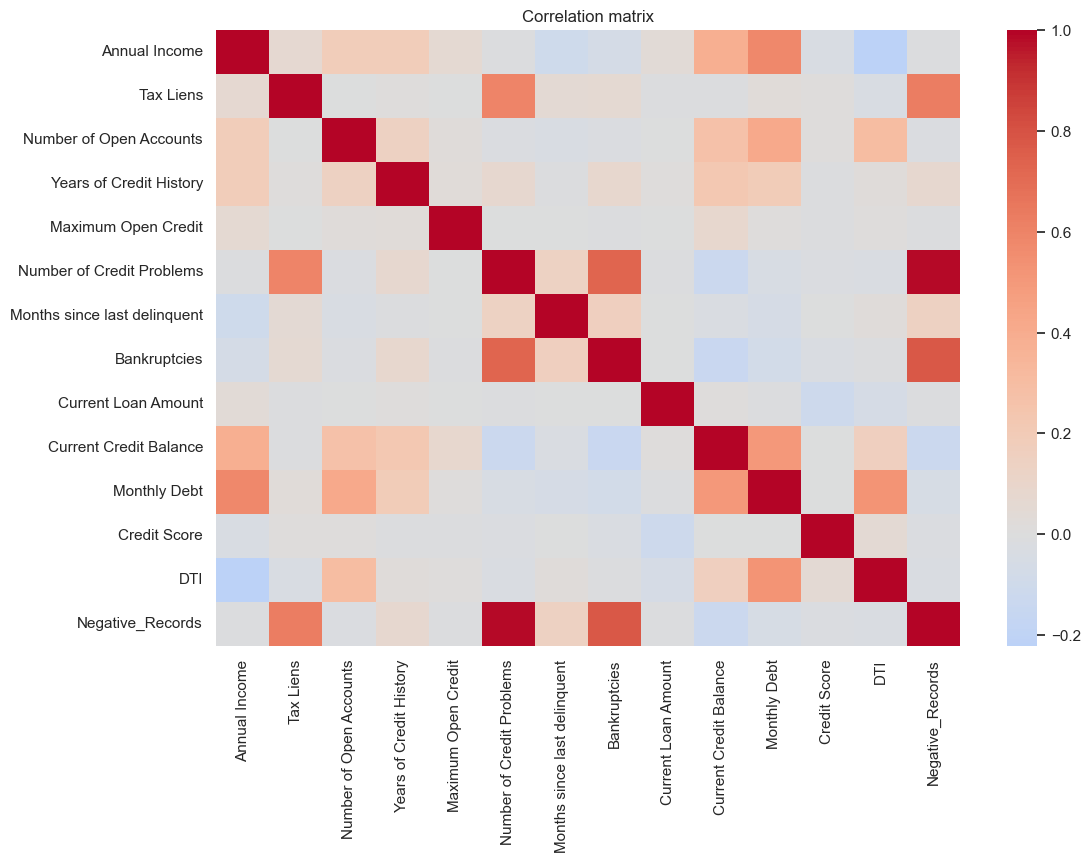

In [16]:
plt.figure(figsize=(12,8))
corr = train_df[num_cols + ["DTI", "Negative_Records"]].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation matrix")
plt.show()

# Шаг 6 — влияние Credit Score на дефолт

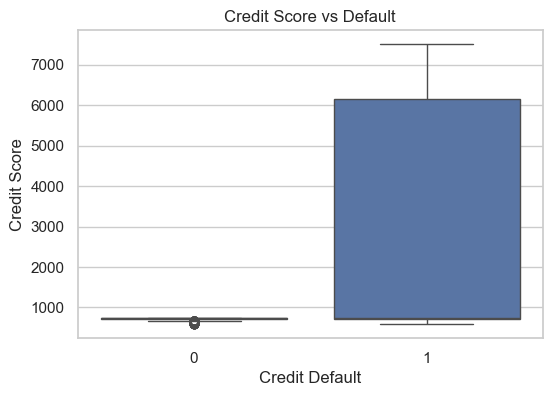

In [17]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x=train_df[TARGET_COL],
    y=train_df["Credit Score"]
)

plt.title("Credit Score vs Default")
plt.show()

# Шаг 7 — влияние DTI на дефолт

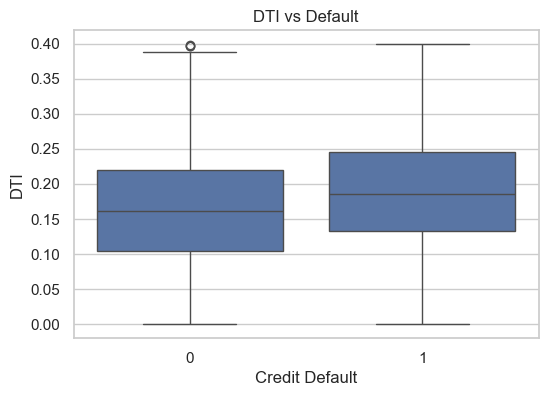

In [19]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x=train_df[TARGET_COL],
    y=train_df["DTI"]
)

plt.title("DTI vs Default")
plt.show()

# Pipeline

# Шаг 6 — train / validation split

In [20]:
X = train_df.drop(columns=[TARGET_COL])
y = train_df[TARGET_COL].astype(int)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Valid shape:", X_valid.shape)

Train shape: (6000, 18)
Valid shape: (1500, 18)


In [21]:
# определяем типы признаков
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical:", cat_cols)
print("Numeric:", num_cols)

Categorical: ['Home Ownership', 'Years in current job', 'Purpose', 'Term']
Numeric: ['Annual Income', 'Tax Liens', 'Number of Open Accounts', 'Years of Credit History', 'Maximum Open Credit', 'Number of Credit Problems', 'Months since last delinquent', 'Bankruptcies', 'Current Loan Amount', 'Current Credit Balance', 'Monthly Debt', 'Credit Score', 'DTI', 'Negative_Records']


# Шаг 8 — создание preprocessing pipeline

In [22]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

print("Pipeline created")

Pipeline created


# Шаг 9 — Logistic Regression (baseline)

In [23]:
lr_model = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_valid)
lr_proba = lr_model.predict_proba(X_valid)[:, 1]

lr_f1 = f1_score(y_valid, lr_pred)
lr_auc = roc_auc_score(y_valid, lr_proba)
lr_gini = 2 * lr_auc - 1

print("Logistic Regression F1:", lr_f1)
print("Logistic Regression AUC:", lr_auc)
print("Logistic Regression Gini:", lr_gini)

print("\nClassification report:\n", classification_report(y_valid, lr_pred))
print("Confusion matrix:\n", confusion_matrix(y_valid, lr_pred))

Logistic Regression F1: 0.5217391304347826
Logistic Regression AUC: 0.7541722365997836
Logistic Regression Gini: 0.5083444731995672

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.71      0.76      1077
           1       0.46      0.61      0.52       423

    accuracy                           0.68      1500
   macro avg       0.64      0.66      0.64      1500
weighted avg       0.72      0.68      0.70      1500

Confusion matrix:
 [[769 308]
 [165 258]]


# Шаг 10 — Decision Tree

In [24]:
tree_model = Pipeline([
    ("preprocess", preprocess),
    ("clf", DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=50,
        random_state=RANDOM_STATE
    ))
])

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_valid)
tree_proba = tree_model.predict_proba(X_valid)[:, 1]

tree_f1 = f1_score(y_valid, tree_pred)
tree_auc = roc_auc_score(y_valid, tree_proba)
tree_gini = 2 * tree_auc - 1

print("Decision Tree F1:", tree_f1)
print("Decision Tree AUC:", tree_auc)
print("Decision Tree Gini:", tree_gini)

print("\nClassification report:\n", classification_report(y_valid, tree_pred))
print("Confusion matrix:\n", confusion_matrix(y_valid, tree_pred))

Decision Tree F1: 0.432258064516129
Decision Tree AUC: 0.7313613026290083
Decision Tree Gini: 0.4627226052580167

Classification report:
               precision    recall  f1-score   support

           0       0.78      0.94      0.85      1077
           1       0.68      0.32      0.43       423

    accuracy                           0.77      1500
   macro avg       0.73      0.63      0.64      1500
weighted avg       0.75      0.77      0.73      1500

Confusion matrix:
 [[1014   63]
 [ 289  134]]


# Шаг 11 — Random Forest

In [25]:
rf_model = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_valid)
rf_proba = rf_model.predict_proba(X_valid)[:, 1]

rf_f1 = f1_score(y_valid, rf_pred)
rf_auc = roc_auc_score(y_valid, rf_proba)
rf_gini = 2 * rf_auc - 1

print("Random Forest F1:", rf_f1)
print("Random Forest AUC:", rf_auc)
print("Random Forest Gini:", rf_gini)

print("\nClassification report:\n", classification_report(y_valid, rf_pred))
print("Confusion matrix:\n", confusion_matrix(y_valid, rf_pred))

Random Forest F1: 0.376865671641791
Random Forest AUC: 0.7640784861196169
Random Forest Gini: 0.5281569722392339

Classification report:
               precision    recall  f1-score   support

           0       0.77      0.99      0.86      1077
           1       0.89      0.24      0.38       423

    accuracy                           0.78      1500
   macro avg       0.83      0.61      0.62      1500
weighted avg       0.80      0.78      0.73      1500

Confusion matrix:
 [[1065   12]
 [ 322  101]]


# Исправленный Random Forest

In [26]:
rf_model = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=10,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_valid)
rf_proba = rf_model.predict_proba(X_valid)[:, 1]

rf_f1 = f1_score(y_valid, rf_pred)
rf_auc = roc_auc_score(y_valid, rf_proba)
rf_gini = 2 * rf_auc - 1

print("Random Forest F1:", rf_f1)
print("Random Forest AUC:", rf_auc)
print("Random Forest Gini:", rf_gini)

print("\nClassification report:\n", classification_report(y_valid, rf_pred))
print("Confusion matrix:\n", confusion_matrix(y_valid, rf_pred))

Random Forest F1: 0.5414364640883977
Random Forest AUC: 0.7645811520048468
Random Forest Gini: 0.5291623040096936

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.78      0.80      1077
           1       0.51      0.58      0.54       423

    accuracy                           0.72      1500
   macro avg       0.67      0.68      0.67      1500
weighted avg       0.74      0.72      0.73      1500

Confusion matrix:
 [[840 237]
 [178 245]]


# Шаг 12 — Gradient Boosting

In [27]:
gb_model = Pipeline([
    ("preprocess", preprocess),
    ("clf", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ))
])

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_valid)
gb_proba = gb_model.predict_proba(X_valid)[:, 1]

gb_f1 = f1_score(y_valid, gb_pred)
gb_auc = roc_auc_score(y_valid, gb_proba)
gb_gini = 2 * gb_auc - 1

print("Gradient Boosting F1:", gb_f1)
print("Gradient Boosting AUC:", gb_auc)
print("Gradient Boosting Gini:", gb_gini)

print("\nClassification report:\n", classification_report(y_valid, gb_pred))
print("Confusion matrix:\n", confusion_matrix(y_valid, gb_pred))

Gradient Boosting F1: 0.4403361344537815
Gradient Boosting AUC: 0.7598354592368698
Gradient Boosting Gini: 0.5196709184737396

Classification report:
               precision    recall  f1-score   support

           0       0.78      0.96      0.86      1077
           1       0.76      0.31      0.44       423

    accuracy                           0.78      1500
   macro avg       0.77      0.64      0.65      1500
weighted avg       0.77      0.78      0.74      1500

Confusion matrix:
 [[1036   41]
 [ 292  131]]


## Лучшей моделью по метрике F1-score оказался: Random Forest

# Шаг 13 — финальное обучение на всём train

### Теперь обучим финальную модель на всём обучающем датасете.

In [28]:
final_model = Pipeline([
    ("preprocess", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=10,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

final_model.fit(X, y)

print("Final model trained")

Final model trained


# Шаг 14 — предсказание test

In [29]:
test_pred = final_model.predict(test_df)

submit = pd.DataFrame({
    "Credit Default": test_pred
})

print("Submit shape:", submit.shape)
submit.head()

Submit shape: (2500, 1)


,Credit Default
0,1
1,1
2,1
3,0
4,0


In [30]:
submit.to_csv("submit_random_forest.csv", index=False)

print("File saved")

File saved


# Шаг 16 — Feature Importance
### Это покажет, какие признаки больше всего влияют на вероятность дефолта.

In [31]:
model_rf = final_model.named_steps["clf"]

feature_names = (
    num_cols +
    list(final_model.named_steps["preprocess"]
         .named_transformers_["cat"]
         .named_steps["onehot"]
         .get_feature_names_out(cat_cols))
)

importances = model_rf.feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi.head(10)

,feature,importance
11,Credit Score,0.270513
8,Current Loan Amount,0.204510
12,DTI,0.071606
0,Annual Income,0.068460
45,Term_Short Term,0.055268
4,Maximum Open Credit,0.053322
44,Term_Long Term,0.046667
10,Monthly Debt,0.042428
9,Current Credit Balance,0.040391
3,Years of Credit History,0.037874


# Шаг 17 — график важности признаков

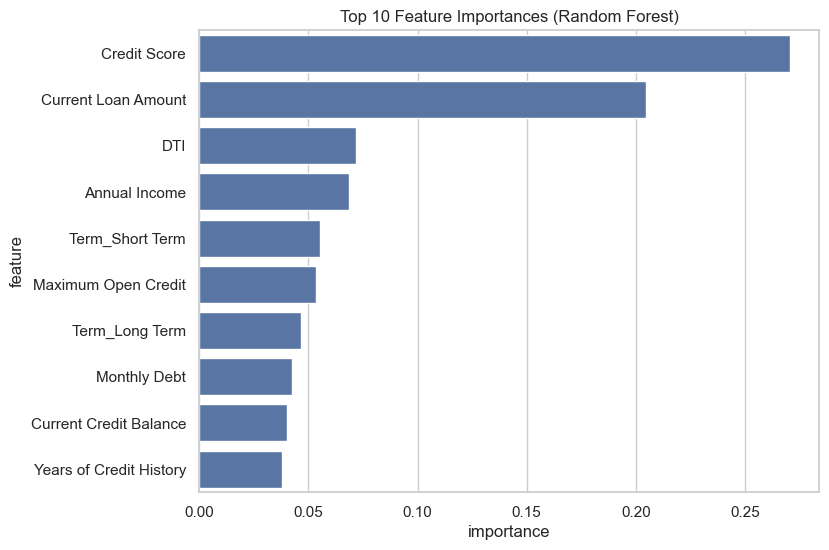

In [33]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=fi.head(10),
    x="importance",
    y="feature"
)

plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

# 2. Описание датасета¶

**Описание каждого признака:**

- `Home Ownership` (Тип жилья): Показывает тип собственности на жилье, например, "Владение", "Аренда" или "Ипотека".
- `Annual Income` (Годовой доход): Отражает годовой доход заемщика в денежном выражении.
- `Years in current job` (Количество лет на текущей работе): Показывает количество лет, которое заемщик проработал на текущем месте работы.
- `Tax Liens` (Налоговые обременения): Отражает наличие налоговых обременений или задолженностей у заемщика.
- `Number of Open Accounts` (Количество открытых счетов): Указывает на общее количество открытых счетов у заемщика, включая кредитные карты, кредитные линии и другие.
- `Years of Credit History` (Количество лет кредитной истории): Показывает общую продолжительность кредитной истории заемщика в годах.
- `Maximum Open Credit` (Максимальная открытая кредитная линия): Отражает максимальную сумму кредитной линии, которая была предоставлена заемщику.
- `Number of Credit Problems` (Количество кредитных проблем): Указывает на количество проблем с кредитом, например, просроченных платежей или коллекций.
- `Months since last delinquent` (Количество месяцев с последней просрочки платежа): Показывает количество месяцев, прошедших с последней просрочки платежа заемщика.
- `Bankruptcies` (Банкротства): Отражает количество банкротств, которые заемщик может иметь в кредитной истории.
- `Purpose` (Цель кредита): Указывает на цель, для которой заемщик берет кредит, например, "автомобиль", "образование" или "недвижимость".
- `Term` (Срок кредита): Показывает срок кредита в месяцах, например, "краткосрочный" или "долгосрочный".
- `Current Loan Amount` (Текущая сумма кредита): Отражает текущую сумму, которую заемщик еще должен выплатить по кредиту.
- `Current Credit` Balance (Текущий кредитный баланс): Указывает на текущий остаток задолженности по кредитам и кредитным линиям.
- `Monthly Debt` (Ежемесячный долг): Показывает сумму ежемесячных платежей по всем задолженностям и кредитам.
- `Credit Score` (Кредитный рейтинг): Отражает кредитный рейтинг заемщика, который оценивает его платежеспособность и кредитный риск.


- `Credit Default` (Кредитный дефолт): **Целевая переменная**, которая указывает, возникнет ли у заемщика дефолт по кредиту (1 - дефолт, 0 - нет).

# 3. Примерное описание этапов выполнения проекта¶

### Построение модели классификации

1. Обзор обучающего датасета
2. Обработка выбросов
3. Обработка пропусков
4. Анализ данных
5. Отбор признаков
6. Балансировка классов
7. Подбор моделей, получение бейзлана
8. Выбор наилучшей модели, настройка гиперпараметров
9. Проверка качества, борьба с переобучением
10. Интерпретация результатов

### Прогнозирование на тестовом датасете

1. Выполнить для тестового датасета те же этапы обработки и постронияния признаков
2. Спрогнозировать целевую переменную, используя модель, построенную на обучающем датасете
3. Прогнозы должны быть для всех примеров из тестового датасета (для всех строк)
4. Соблюдать исходный порядок примеров из тестового датасета

# 4. Алгоритм оценки работы

### Оценка отлично (5)
- Реализован полный пайплайн разработки ML-модели:
1. `EDA-анализ` (Разведочный анализ данных)
2. `Preprocessing` (предобработка данных)
3. `FE` (Генерация признаков - ПРИ НЕОБХОДИМОСТИ (она не обязательно должна быть в рамках этой задачи))
4. `Моделирование` (построение baseline модели, подбор гиперпараметров, валидация) 
- Проведено сравнение самописных алгоритмов decision tree, random forest, gradient boosting и алгоритмов из "коробки"
- Проведено сравнение всех моделей (логистической регрессии, деревьев решений, ансамбль деревьев решений, любой из моделей градинтного бустинга (catboost, xgboost, lightgbm)) и сделаны соответствующие выводы
- Использована корректная метрика оценки качества `F1-score` и ее значение `> 0.5`
- Использована дополнительная метрика оценки качества `Gini`
- Код запушен в публичный репозиторий на GitHub и составлена понятная, развернутая документация в формате README.md

### Оценка хорошо (4)
- Реализован полный пайплайн разработки ML-модели:
1. `EDA-анализ` (Разведочный анализ данных)
2. `Preprocessing` (предобработка данных)
3. `FE` (Генерация признаков - ПРИ НЕОБХОДИМОСТИ (она не обязательно должна быть в рамках этой задачи))
4. `Моделирование` (построение baseline модели, подбор гиперпараметров, валидация)
- ML-модели построены на основании алгоритма из "коробки" 
- Использована корректная метрика оценки качества `F1-score` и ее значение `> 0.5`
- Использована дополнительная метрика оценки качества `Gini`
- Код запушен в публичный репозиторий на GitHub и составлена понятная, развернутая документация в формате README.md

### Оценка удовлетворительно (3)
- Частично проведен пайплайн разработки ML-модели (одна или несколько итераций из пайплайна разработки ML отсутствуют): 
1. `EDA-анализ` (Разведочный анализ данных)
2. `Preprocessing` (предобработка данных)
3. `FE` (Генерация признаков - ПРИ НЕОБХОДИМОСТИ (она не обязательно должна быть в рамках этой задачи))
4. `Моделирование` (построение baseline модели, подбор гиперпараметров, валидация)
- Построена одна из предложенных ML-моделей (логистической регрессии, деревьев решений, ансамбль деревьев решений, любой из моделей градинтного бустинга (catboost, xgboost, lightgbm)) на основании алгоритма из "коробки" 
- Использована либо метрика оценки качества `F1-score` и ее значение `> 0.5`, либо `Gini`
- Код запушен в публичный репозиторий на GitHub, но документация в формате README.md не составлена или по ней не ясны шаги реализации решения и ключевые выводы

### Оценка не удовлетворительно (2)
- Код не запушен в публичный репозиторий на GitHub

**Либо**

- Частично проведен пайплайн разработки ML-модели (одна или несколько итераций из пайплайна разработки ML отсутствуют) или не проведен вовсе: 
1. `EDA-анализ` (Разведочный анализ данных)
2. `Preprocessing` (предобработка данных)
3. `FE` (Генерация признаков - ПРИ НЕОБХОДИМОСТИ (она не обязательно должна быть в рамках этой задачи))
4. `Моделирование` (построение baseline модели, подбор гиперпараметров, валидация)
- ML-модели построены на основании алгоритма из "коробки" (scikit-learn) или не построены вовсе
- Использована некорректная метрика оценки качества, не считая `Gini`, или корректная метрика оценки качества `F1-score`, но ее значение `< 0.5`
- Код запушен в публичный репозиторий на GitHub, но отсутствует